# Network Analysis Pipeline in Google Colab

This notebook rebuilds the network from a CSV edge list, draws it using **fixed node positions** that match your figure, and computes the following measures for each node:

- **Raw degree**
- **Normalized degree centrality**
- **Raw betweenness centrality**
- **Normalized betweenness centrality**
- **Closeness centrality**
- **Eigenvector centrality**
- **Clustering coefficient**

At the end, the notebook saves the results as a CSV file and downloads it automatically.

The second part of the notebook calculates network-level, global metrics of graphs.

## 1. Install and import libraries

We use:
- `pandas` for reading and saving tables
- `networkx` for building and analyzing the graph
- `matplotlib` for drawing the network
- `google.colab.files` for uploading and downloading files in Colab

In [1]:
!pip install -q networkx matplotlib pandas

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from google.colab import files

## 2. Upload the CSV file

The CSV should have this structure:

```csv
source,target
A,B
A,C
...
```

Each row represents one **undirected edge** between two nodes.

In [2]:
uploaded = files.upload()

# Use the uploaded filename automatically.
csv_filename = list(uploaded.keys())[0]
print(f"Uploaded file: {csv_filename}")

# Read the edge list into a pandas DataFrame.
df = pd.read_csv(csv_filename)

# Preview the first few rows so we can verify the structure.
df.head()

Saving network_edges.csv to network_edges.csv
Uploaded file: network_edges.csv


,source,target
0,A,B
1,A,C
2,A,D
3,B,C
4,B,F


## 3. Construct the network

We create an undirected graph because the uploaded network does not show arrow directions.

Then we add each `(source, target)` pair from the CSV as an edge.

In [3]:
G = nx.Graph()

for _, row in df.iterrows():
    G.add_edge(row['source'], row['target'])

print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")
print("Nodes:", sorted(G.nodes()))

Number of nodes: 8
Number of edges: 16
Nodes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']


## 4. Define fixed node positions

Instead of using an automatic layout like `spring_layout`, we manually specify coordinates.

This is useful because:
- it keeps the drawing consistent every time
- it makes the graph visually resemble your original figure
- it is easier to compare the reproduced network with the source image

In [4]:
pos = {
    'A': (-2.0,  1.0),
    'B': ( 0.0,  1.2),
    'C': (-1.0,  0.0),
    'D': (-2.5, -0.5),
    'E': (-1.2, -1.5),
    'F': ( 0.2, -0.8),
    'G': ( 1.5, -1.5),
    'H': ( 1.5,  0.0)
}

pos

{'A': (-2.0, 1.0),
 'B': (0.0, 1.2),
 'C': (-1.0, 0.0),
 'D': (-2.5, -0.5),
 'E': (-1.2, -1.5),
 'F': (0.2, -0.8),
 'G': (1.5, -1.5),
 'H': (1.5, 0.0)}

## 5. Draw the network

Here we visualize the graph using the fixed positions above.

Important drawing settings:
- `with_labels=True` shows node names
- `node_size` controls the circle size
- `edgecolors='black'` makes node outlines visible
- `axis('off')` hides the coordinate axes because they are not meaningful for the graph itself

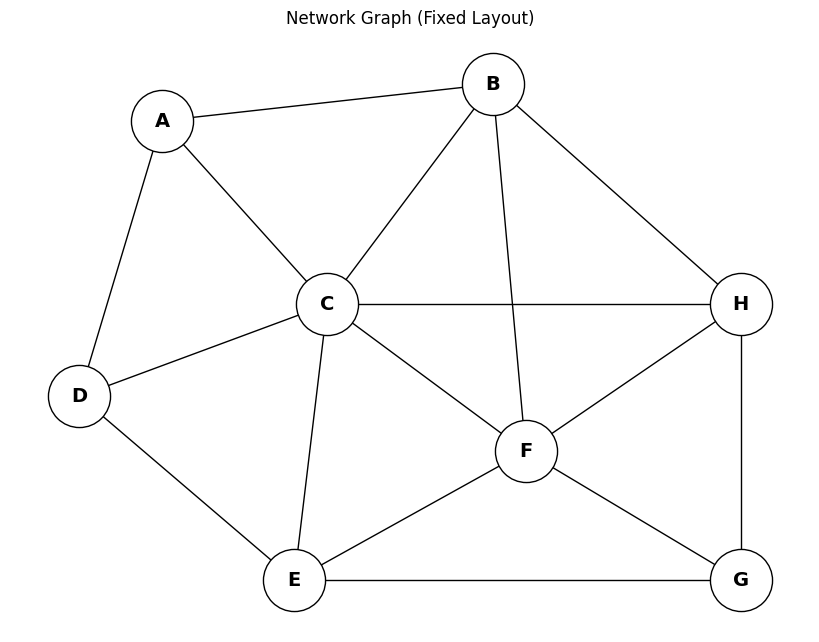

In [6]:
plt.figure(figsize=(8, 6))

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=2000,
    node_color='white',
    edgecolors='black',
    font_size=14,
    font_weight='bold'
)

plt.title('Network Graph (Fixed Layout)')
plt.axis('off')
plt.show()

## 6. Compute node-level measures

Below is a short explanation of each measure:

### Raw degree
The number of direct neighbors a node has.

### Normalized degree centrality
The raw degree divided by the maximum possible degree, so values are scaled between 0 and 1.

### Raw betweenness centrality
Counts how often a node lies on shortest paths between other nodes, without normalization.

### Normalized betweenness centrality
The same concept as betweenness, but scaled for easier comparison.

### Closeness centrality
Measures how close a node is, on average, to all other nodes in the network.

### Eigenvector centrality
Gives higher scores to nodes that are connected to other important nodes.

### Clustering coefficient
Measures how strongly a node's neighbors are connected to one another.

In [7]:
# Raw degree: actual number of connections for each node.
raw_degree = dict(G.degree())

# Degree centrality: normalized version of degree.
degree_centrality = nx.degree_centrality(G)

# Raw betweenness: not normalized.
raw_betweenness = nx.betweenness_centrality(G, normalized=False)

# Normalized betweenness.
betweenness_centrality = nx.betweenness_centrality(G, normalized=True)

# Closeness centrality.
closeness_centrality = nx.closeness_centrality(G)

# Eigenvector centrality.
eigenvector_centrality = nx.eigenvector_centrality(G, max_iter=1000)

# Local clustering coefficient for each node.
clustering_coeff = nx.clustering(G)

print('Measures computed successfully.')

Measures computed successfully.


## 7. Combine the results into one table

This table puts every metric side by side so it is easier to inspect, compare, and export.

In [8]:
results = pd.DataFrame({
    'Node': list(G.nodes()),
    'Degree_raw': [raw_degree[n] for n in G.nodes()],
    'Degree_norm': [degree_centrality[n] for n in G.nodes()],
    'Betweenness_raw': [raw_betweenness[n] for n in G.nodes()],
    'Betweenness_norm': [betweenness_centrality[n] for n in G.nodes()],
    'Closeness': [closeness_centrality[n] for n in G.nodes()],
    'Eigenvector': [eigenvector_centrality[n] for n in G.nodes()],
    'ClusteringCoeff': [clustering_coeff[n] for n in G.nodes()]
})

# Sort by raw degree first, then raw betweenness.
results = results.sort_values(
    by=['Degree_raw', 'Betweenness_raw'],
    ascending=[False, False]
).reset_index(drop=True)

# Round selected columns for readability.
numeric_cols = [
    'Degree_norm', 'Betweenness_raw', 'Betweenness_norm',
    'Closeness', 'Eigenvector', 'ClusteringCoeff'
]
results[numeric_cols] = results[numeric_cols].round(6)

results

,Node,Degree_raw,Degree_norm,Betweenness_raw,Betweenness_norm,Closeness,Eigenvector,ClusteringCoeff
0,C,6,0.857143,4.833333,0.230159,0.875000,0.477682,0.466667
1,F,5,0.714286,2.000000,0.095238,0.777778,0.430485,0.600000
2,E,4,0.571429,2.166667,0.103175,0.700000,0.339732,0.500000
3,B,4,0.571429,1.333333,0.063492,0.700000,0.363609,0.666667
4,H,4,0.571429,1.166667,0.055556,0.700000,0.365373,0.666667
5,D,3,0.428571,0.666667,0.031746,0.636364,0.255463,0.666667
6,A,3,0.428571,0.500000,0.023810,0.583333,0.260039,0.666667
7,G,3,0.428571,0.333333,0.015873,0.583333,0.269246,0.666667


## 8. Save the results as a CSV file

This creates a file named `network_centrality_results.csv` in the Colab session.

In [9]:
output_file = 'network_centrality_results.csv'
results.to_csv(output_file, index=False)

files.download(output_file)

Saved results to: network_centrality_results.csv


## 9. Compute whole-network measures

So far, the analysis focused on **node-level measures**.  
This next step computes **graph-level measures**, which describe the structure of the network as a whole.

### Measures included

- **Average clustering coefficient**: the mean of the local clustering coefficients across all nodes
- **Global clustering coefficient** (transitivity): the overall tendency of nodes to form triangles in the network
- **Diameter**: the longest shortest-path distance between any pair of nodes
- **Average path length**: the average shortest-path distance across all node pairs
- **Density**: the proportion of existing edges out of all possible edges

Because these path-based measures require connectivity, the code below assumes the graph is connected.  
For this network, that condition is satisfied.

In [10]:
# Average clustering coefficient:
# mean of node-level clustering coefficients.
avg_clustering = nx.average_clustering(G)

# Global clustering coefficient (also called transitivity):
# based on closed triplets / all triplets.
global_clustering = nx.transitivity(G)

# Diameter:
# the largest shortest-path distance in the graph.
diameter = nx.diameter(G)

# Average shortest-path length.
avg_path_length = nx.average_shortest_path_length(G)

# Density:
# fraction of realized edges among all possible edges.
density = nx.density(G)

network_summary = pd.DataFrame({
    'Metric': [
        'AverageClusteringCoeff',
        'GlobalClusteringCoeff',
        'Diameter',
        'AveragePathLength',
        'Density'
    ],
    'Value': [
        avg_clustering,
        global_clustering,
        diameter,
        avg_path_length,
        density
    ]
})

network_summary['Value'] = network_summary['Value'].round(6)
network_summary

,Metric,Value
0,AverageClusteringCoeff,0.612500
1,GlobalClusteringCoeff,0.576923
2,Diameter,3.000000
3,AveragePathLength,1.464286
4,Density,0.571429


## 11. Save the whole-network measures

This creates a second CSV file containing the graph-level summary metrics.

In [ ]:
summary_file = 'network_global_metrics.csv'
network_summary.to_csv(summary_file, index=False)
files.download(summary_file)
